# `Danish Housing Prices`
* Dataset: Danish Residential Housing Prices 1992-2024
* Source: [Kaggle](https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024)
* Goal: Predict sales price

This dataset was found on Kaggle.com, and shows housing sales records in Denmark from 1992 through the 3rd quarter of 2024. This data will be leveraged to identify the factors most affecting sales prices in order to predict future home sales prices.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [38]:
!pip install gdown
import gdown

gdown.download('https://drive.google.com/uc?id=1Xrv-k1G1Qk18GaSIuWMsm6foLEmjHumd')
df = pd.read_parquet('DKHousingPrices.parquet')
df

Downloading...
From: https://drive.google.com/uc?id=1Xrv-k1G1Qk18GaSIuWMsm6foLEmjHumd
To: /content/DKHousingPrices.parquet
100%|██████████| 43.0M/43.0M [00:01<00:00, 22.9MB/s]


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
0,2024-10-26,2024Q4,0,Villa,regular_sale,1974,4350000,0.0,5,215.0,20232.558594,Kildevangen 5,8382,Hinnerup,East & mid jutland,Jutland,3.1,NaN,NaN
1,2024-10-26,2024Q4,2,Summerhouse,regular_sale,1956,450000,0.0,3,36.0,12500.000000,Lykkestien 2,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN
2,2024-10-26,2024Q4,1,Farm,regular_sale,1955,6600000,0.0,3,180.0,36666.667969,Sæderupvej 58,9260,Gistrup,North jutland,Jutland,3.1,NaN,NaN
3,2024-10-25,2024Q4,3,Apartment,family_sale,1945,1495000,0.0,2,64.0,23359.375000,"Tage-Hansens Gade 5, 1. tv",8000,Aarhus C,East & mid jutland,Jutland,3.1,NaN,NaN
4,2024-10-25,2024Q4,4,Villa,regular_sale,1967,3375000,0.0,5,176.0,19176.136719,Chr.Winthers Vej 5,8600,Silkeborg,East & mid jutland,Jutland,3.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507903,1992-01-05,1992Q1,1505861,Villa,regular_sale,1972,1004000,0.0,6,156.0,6435.897461,Tornekrogen 9,3500,Værløse,North Zealand,Zealand,9.5,2.1,10.14
1507904,1992-01-05,1992Q1,1505860,Villa,regular_sale,1880,750000,0.0,7,252.0,2976.190430,Bygaden 19,8410,Rønde,East & mid jutland,Jutland,9.5,2.1,10.14
1507905,1992-01-05,1992Q1,1505859,Townhouse,regular_sale,1890,290000,0.0,4,73.0,3972.602783,Museumsgade 26,4930,Maribo,Other islands,Zealand,9.5,2.1,10.14
1507906,1992-01-05,1992Q1,1505858,Villa,family_sale,1972,750000,0.0,4,160.0,4687.500000,P O Pedersens Vej 40,7500,Holstebro,South jutland,Jutland,9.5,2.1,10.14


In [39]:
#Rename columns for clarity
df_name = df.rename(columns={'date': 'Date', 'quarter': 'Quarter', 'house_id': 'House ID', 'house_type': 'House Type', 'sales_type': 'Sales Type', 'year_build': 'Year Built', 'purchase_price': 'Purchase Price  (Target)', '%_change_between_offer_and_purchase': '% Change Between Offer and Purchase', 'no_rooms': '# of Rooms', 'sqm': 'Size (sq meters)', 'sqm_price': 'Price/sq meter', 'address': 'Address', 'zip_code': 'Zip Code', 'city': 'City', 'area': 'Area', 'region': 'Region', 'nom_interest_rate%': 'Nominal Interest Rate', 'dk_ann_infl_rate%': 'Annual Danish Inflation Rate', 'yield_on_mortgage_credit_bonds%': '30 year rate'})

#Drop 2024 as it will be a holdout
df_name = df_name.drop(df_name[df_name['Date'].dt.year == 2024].index)
df_name

,Date,Quarter,House ID,House Type,Sales Type,Year Built,Purchase Price (Target),% Change Between Offer and Purchase,# of Rooms,Size (sq meters),Price/sq meter,Address,Zip Code,City,Area,Region,Nominal Interest Rate,Annual Danish Inflation Rate,30 year rate
61235,2023-12-31,2023Q4,45619,Apartment,regular_sale,1943,7040000,0.0,5,132.0,53333.332031,"Spangsbjerggade 26, 2. th",6700,Esbjerg,South jutland,Jutland,3.6,3.31,4.79
61236,2023-12-31,2023Q4,45624,Villa,regular_sale,1986,11000000,-15.0,6,193.0,56994.820312,Klitgårdsvej 3,9990,Skagen,North jutland,Jutland,3.6,3.31,4.79
61237,2023-12-31,2023Q4,45623,Apartment,family_sale,1917,4292500,0.0,4,166.0,25858.433594,"Ved Arehøj 2, 1. tv",2900,Hellerup,"Capital, Copenhagen",Zealand,3.6,3.31,4.79
61238,2023-12-31,2023Q4,45622,Villa,regular_sale,1956,965000,0.0,3,117.0,8247.863281,Holstebrovej 24,6900,Skjern,South jutland,Jutland,3.6,3.31,4.79
61239,2023-12-31,2023Q4,45621,Summerhouse,regular_sale,1974,1275000,-4.0,4,62.0,20564.515625,Jasonvej 2,9982,Ã lbæk,North jutland,Jutland,3.6,3.31,4.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507903,1992-01-05,1992Q1,1505861,Villa,regular_sale,1972,1004000,0.0,6,156.0,6435.897461,Tornekrogen 9,3500,Værløse,North Zealand,Zealand,9.5,2.10,10.14
1507904,1992-01-05,1992Q1,1505860,Villa,regular_sale,1880,750000,0.0,7,252.0,2976.190430,Bygaden 19,8410,Rønde,East & mid jutland,Jutland,9.5,2.10,10.14
1507905,1992-01-05,1992Q1,1505859,Townhouse,regular_sale,1890,290000,0.0,4,73.0,3972.602783,Museumsgade 26,4930,Maribo,Other islands,Zealand,9.5,2.10,10.14
1507906,1992-01-05,1992Q1,1505858,Villa,family_sale,1972,750000,0.0,4,160.0,4687.500000,P O Pedersens Vej 40,7500,Holstebro,South jutland,Jutland,9.5,2.10,10.14


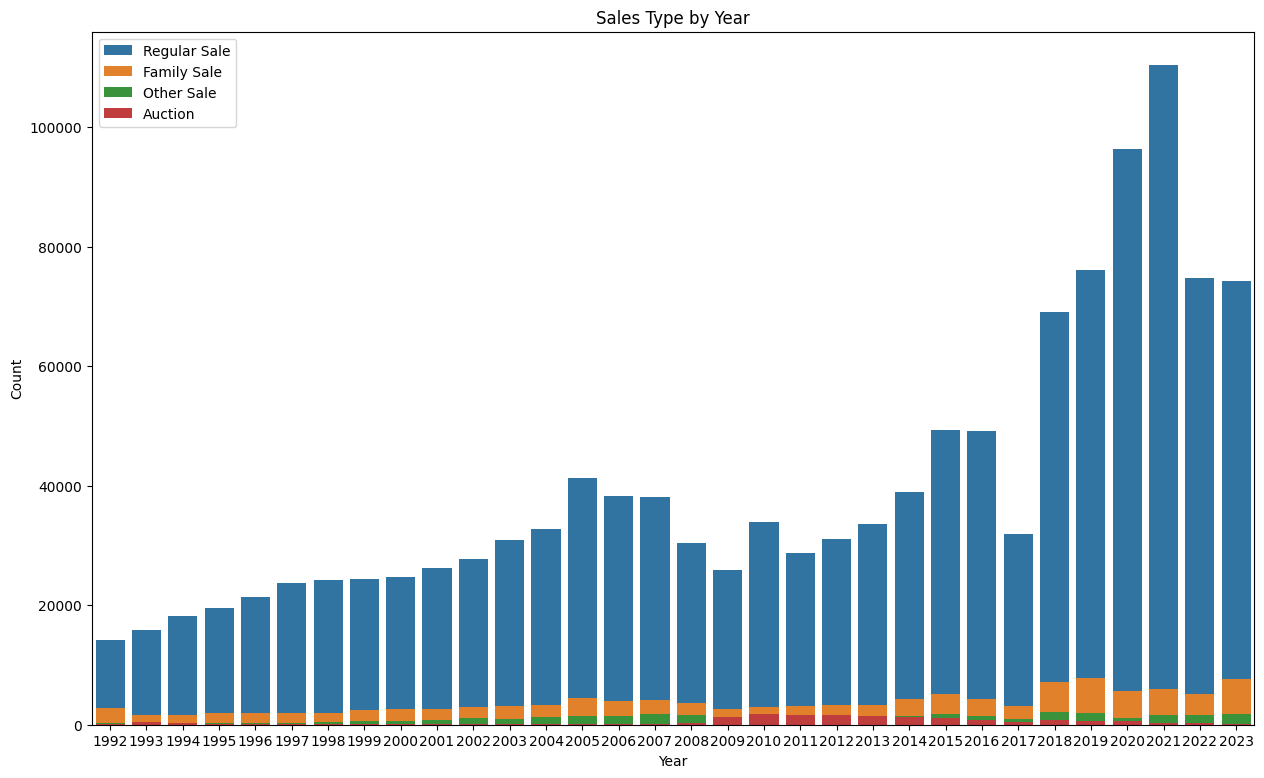

In [40]:
#How are homes being sold on a year to year basis?
#Is there a sales method that to focus on?

#Create variables for sales type year to year
regular = df_name[df_name['Sales Type'] == 'regular_sale'].groupby(df_name['Date'].dt.year).size()
family = df_name[df_name['Sales Type'] == 'family_sale'].groupby(df_name['Date'].dt.year).size()
other = df_name[df_name['Sales Type'] == 'other_sale'].groupby(df_name['Date'].dt.year).size()
auction = df_name[df_name['Sales Type'] == 'auction'].groupby(df_name['Date'].dt.year).size()

#plot sales type year to year
plt.figure(figsize=(15, 9))
sns.barplot(x=regular.index, y=regular.values, label='Regular Sale')
sns.barplot(x=family.index, y=family.values, label='Family Sale')
sns.barplot(x=other.index, y=other.values, label='Other Sale')
sns.barplot(x=auction.index, y=auction.values, label='Auction')

plt.legend()
plt.title('Sales Type by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


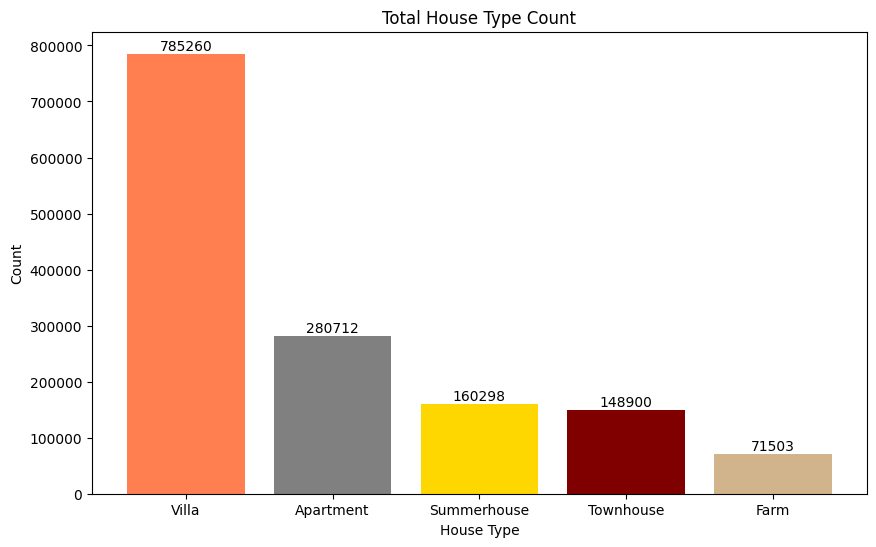

In [41]:
#Total home sales by house type
house_type_counts = df_name['House Type'].value_counts()

house_colors = ['coral','gray','gold','maroon','tan']

plt.figure(figsize=(10, 6))
bars = plt.bar(house_type_counts.index, house_type_counts.values, color=house_colors)
plt.title('Total House Type Count')
plt.xlabel('House Type')
plt.ylabel('Count')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, round(yval, 2), ha='center', va='bottom') # +1000 for offset

plt.show()

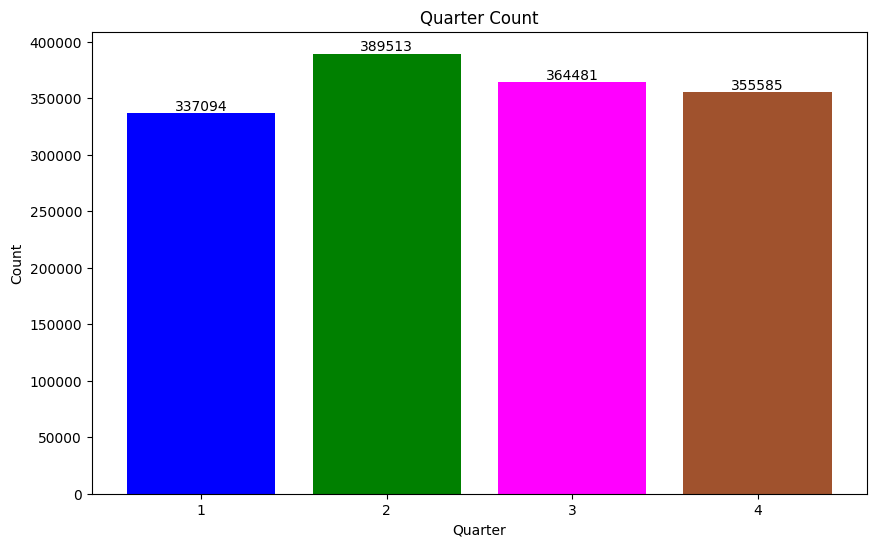

In [42]:
#Is there a time of year when home sales peak? We break it down into quarters:
df_name['Quarter'] = pd.PeriodIndex(df_name['Quarter'], freq='Q').to_timestamp()
df_name['quarters'] = df_name['Quarter'].dt.quarter
quarter_count = df_name['quarters'].value_counts()
quarter_count = quarter_count.sort_index()

quarter_colors = ['blue','green','magenta','sienna']

plt.figure(figsize=(10, 6))
plt.bar(quarter_count.index, quarter_count.values, color=quarter_colors)
plt.title('Quarter Count')
plt.xlabel('Quarter')
plt.ylabel('Count')
plt.xticks(range(1, 5))

for bar in plt.gca().patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), round(bar.get_height(), 2), ha='center', va='bottom')

plt.show()

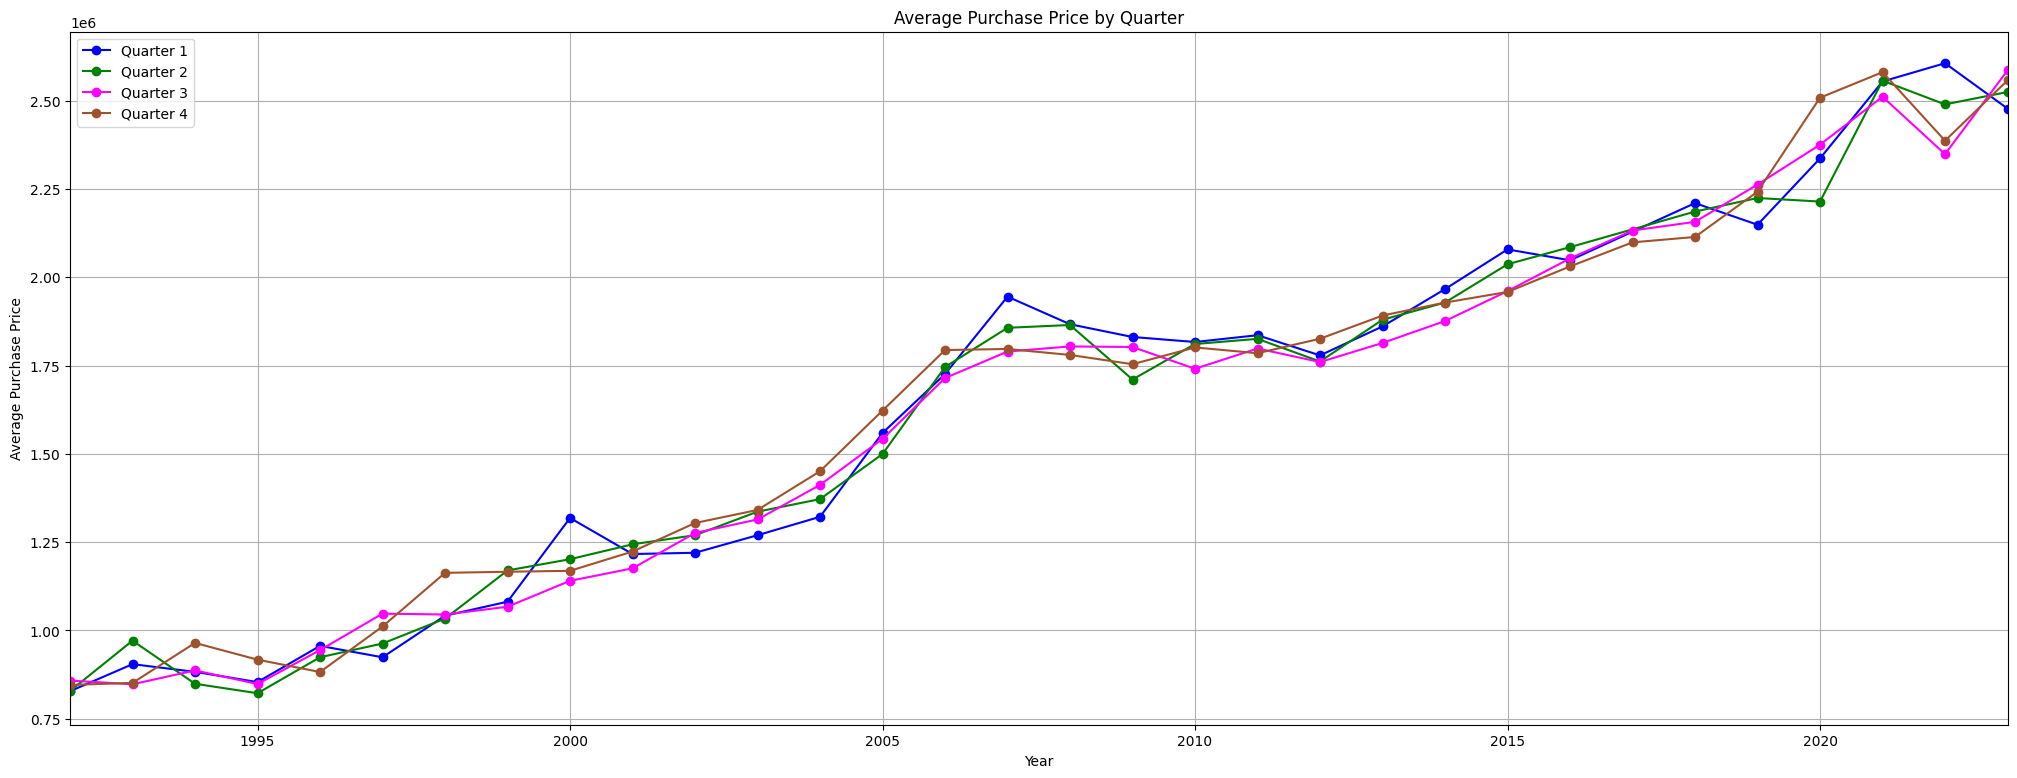

In [43]:
#Split quarter averages into different quarter lines from 1992 through 2023
df_name['Quarter'] = pd.PeriodIndex(df_name['Quarter'], freq='Q').to_timestamp()
df_name['quarters'] = df_name['Quarter'].dt.quarter
quarter_count = df_name['quarters'].value_counts()
quarter_count = quarter_count.sort_index()

#Chart the individual quarters from 1992
plt.figure(figsize=(25, 9))
for quarter in range(1, 5):
    quarter_data = df_name[df_name['quarters'] == quarter]
    quarter_data = quarter_data.groupby(quarter_data['Date'].dt.year)['Purchase Price  (Target)'].mean()
    plt.plot(quarter_data.index, quarter_data.values, label=f'Quarter {quarter}', color=quarter_colors[quarter-1], marker='o')

plt.legend()
plt.title('Average Purchase Price by Quarter')
plt.xlabel('Year')
plt.ylabel('Average Purchase Price')
plt.grid(True)
plt.xlim(1992, 2023)
plt.show()

Prices trend overall at a similar rate between quarters. Despite the previous bar chart showing that Q2 is busiest for sales, it does not cause prices to vary in reaction.

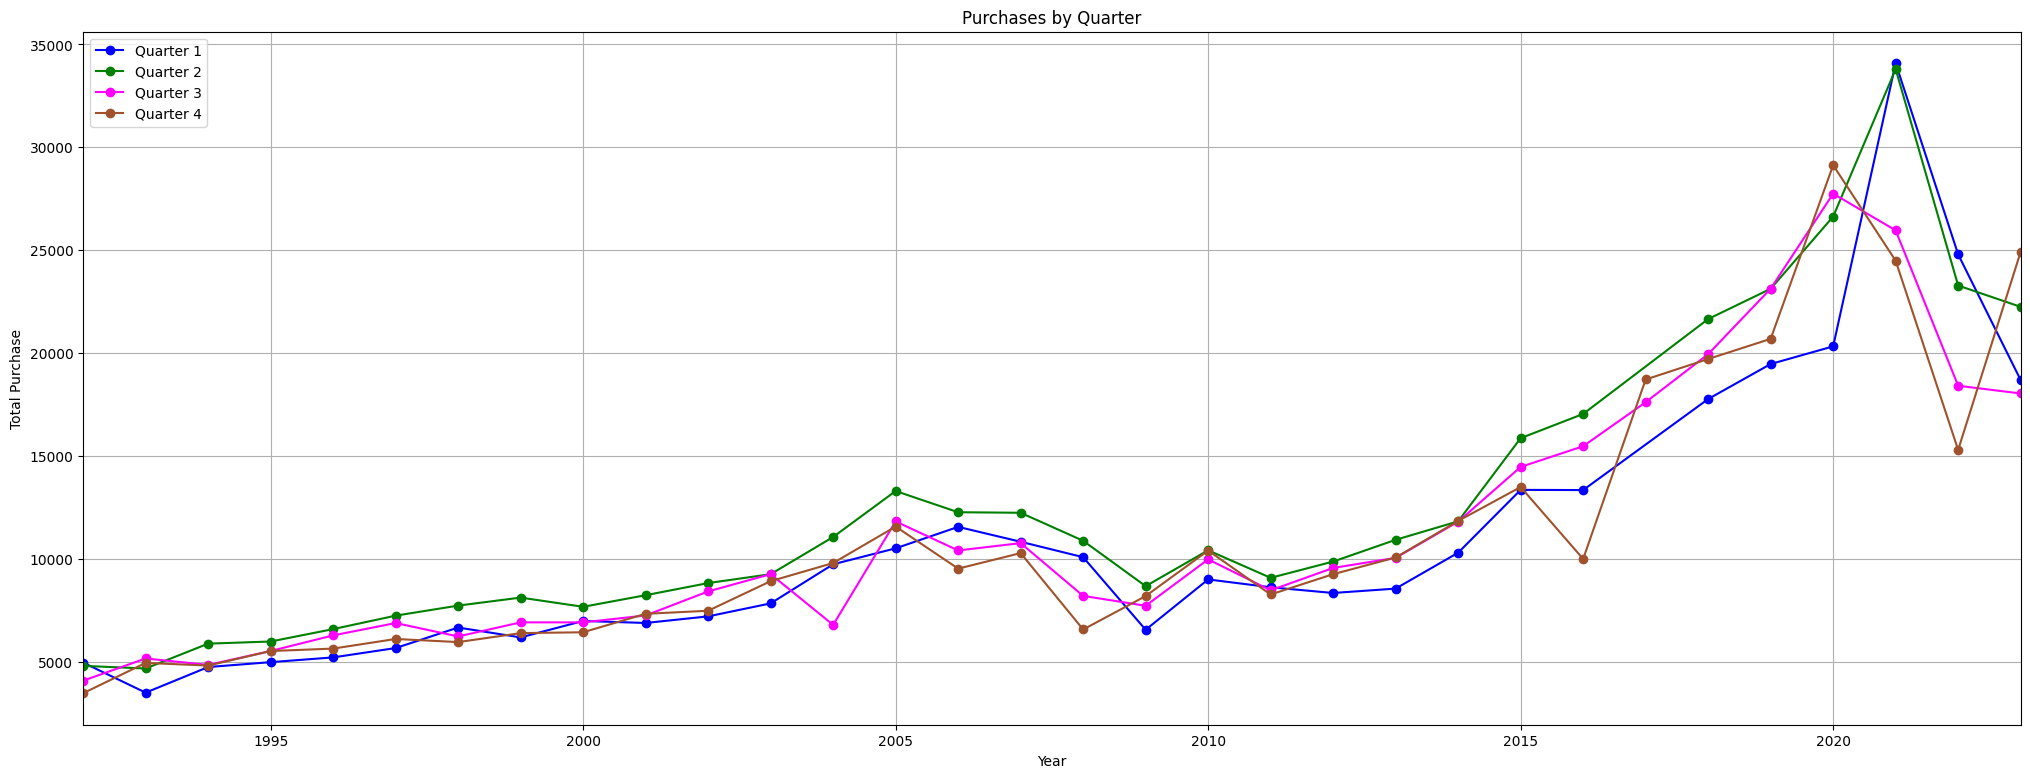

In [44]:
#Split quarterly sales counts from 1992 through 2023
df_name['Quarter'] = pd.PeriodIndex(df_name['Quarter'], freq='Q').to_timestamp()
df_name['quarters'] = df_name['Quarter'].dt.quarter
quarter_count = df_name['quarters'].value_counts()
quarter_count = quarter_count.sort_index()

#Chart the individual quarters from 1992
plt.figure(figsize=(25, 9))
for quarter in range(1, 5):
    quarter_data = df_name[df_name['quarters'] == quarter]
    quarter_data = quarter_data.groupby(quarter_data['Date'].dt.year)['Purchase Price  (Target)'].count()
    plt.plot(quarter_data.index, quarter_data.values, label=f'Quarter {quarter}', color=quarter_colors[quarter-1], marker='o')

plt.legend()
plt.title('Purchases by Quarter')
plt.xlabel('Year')
plt.ylabel('Total Purchase')
plt.xlim(1992, 2023)
plt.grid(True)
plt.show()

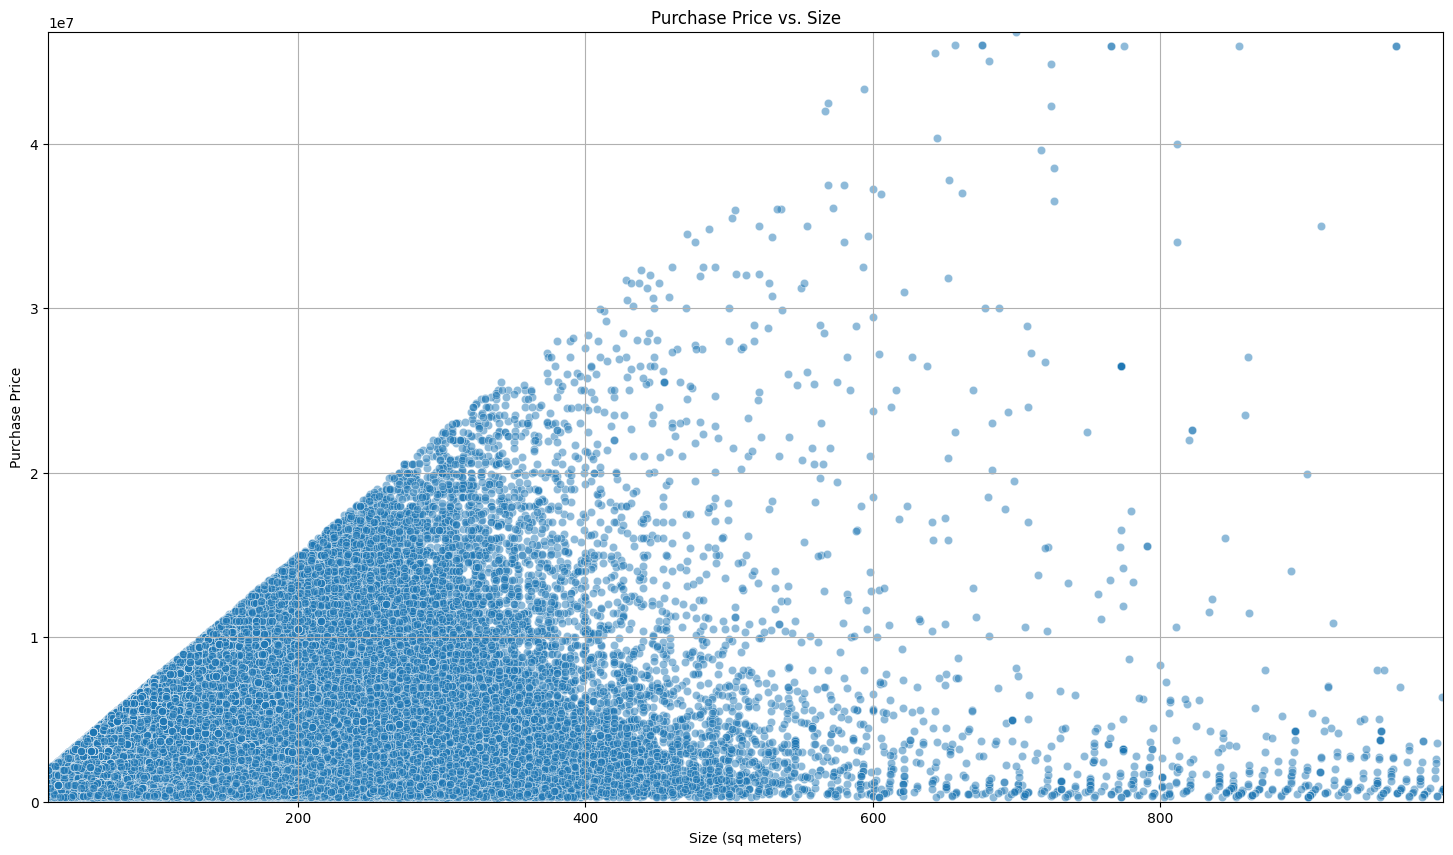

In [45]:
price_min = df_name['Purchase Price  (Target)'].min()
price_max = df_name['Purchase Price  (Target)'].max()

#Visualize Purchase Price per Size
plt.figure(figsize=(18,10))
sns.scatterplot(data=df_name, x='Size (sq meters)', y='Purchase Price  (Target)', alpha=0.5)
plt.title(f'Purchase Price vs. Size')
plt.xlabel('Size (sq meters)')
plt.ylabel('Purchase Price')
plt.grid(True)
plt.xlim(df_name['Size (sq meters)'].min(), df_name['Size (sq meters)'].max())
plt.ylim(0, price_max)
plt.show()

#ML Modeling

In [74]:

df_train = df.rename(columns={'date': 'Date', 'quarter': 'Quarter', 'house_id': 'House ID', 'house_type': 'House Type', 'sales_type': 'Sales Type', 'year_build': 'Year Built', 'purchase_price': 'Purchase Price', '%_change_between_offer_and_purchase': '% Change Between Offer and Purchase', 'no_rooms': '# of Rooms', 'sqm': 'Size', 'sqm_price': 'Price/sq meter', 'address': 'Address', 'zip_code': 'Zip Code', 'city': 'City', 'area': 'Area', 'region': 'Region', 'nom_interest_rate%': 'Nominal Interest Rate', 'dk_ann_infl_rate%': 'Annual Danish Inflation Rate', 'yield_on_mortgage_credit_bonds%': '30 year rate'})
#Create a sales_year variable using the year (first 4 digits) in 'Date'
df_train['sales_year'] = df_train['Date'].dt.year
df_train = df_train.drop(df_train[df_train['Sales Type'] != 'regular_sale'].index)

df_train

,Date,Quarter,House ID,House Type,Sales Type,Year Built,Purchase Price,% Change Between Offer and Purchase,# of Rooms,Size,Price/sq meter,Address,Zip Code,City,Area,Region,Nominal Interest Rate,Annual Danish Inflation Rate,30 year rate,sales_year
0,2024-10-26,2024Q4,0,Villa,regular_sale,1974,4350000,0.0,5,215.0,20232.558594,Kildevangen 5,8382,Hinnerup,East & mid jutland,Jutland,3.1,NaN,NaN,2024
1,2024-10-26,2024Q4,2,Summerhouse,regular_sale,1956,450000,0.0,3,36.0,12500.000000,Lykkestien 2,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN,2024
2,2024-10-26,2024Q4,1,Farm,regular_sale,1955,6600000,0.0,3,180.0,36666.667969,Sæderupvej 58,9260,Gistrup,North jutland,Jutland,3.1,NaN,NaN,2024
4,2024-10-25,2024Q4,4,Villa,regular_sale,1967,3375000,0.0,5,176.0,19176.136719,Chr.Winthers Vej 5,8600,Silkeborg,East & mid jutland,Jutland,3.1,NaN,NaN,2024
5,2024-10-24,2024Q4,14,Villa,regular_sale,1979,3000000,0.0,6,208.0,14423.077148,Vesterled 7,8300,Odder,East & mid jutland,Jutland,3.1,NaN,NaN,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507902,1992-01-05,1992Q1,1505862,Villa,regular_sale,1970,975000,0.0,7,186.0,5241.935547,Margrethe Alle 44,2690,Karlslunde,"Capital, Copenhagen",Zealand,9.5,2.1,10.14,1992
1507903,1992-01-05,1992Q1,1505861,Villa,regular_sale,1972,1004000,0.0,6,156.0,6435.897461,Tornekrogen 9,3500,Værløse,North Zealand,Zealand,9.5,2.1,10.14,1992
1507904,1992-01-05,1992Q1,1505860,Villa,regular_sale,1880,750000,0.0,7,252.0,2976.190430,Bygaden 19,8410,Rønde,East & mid jutland,Jutland,9.5,2.1,10.14,1992
1507905,1992-01-05,1992Q1,1505859,Townhouse,regular_sale,1890,290000,0.0,4,73.0,3972.602783,Museumsgade 26,4930,Maribo,Other islands,Zealand,9.5,2.1,10.14,1992


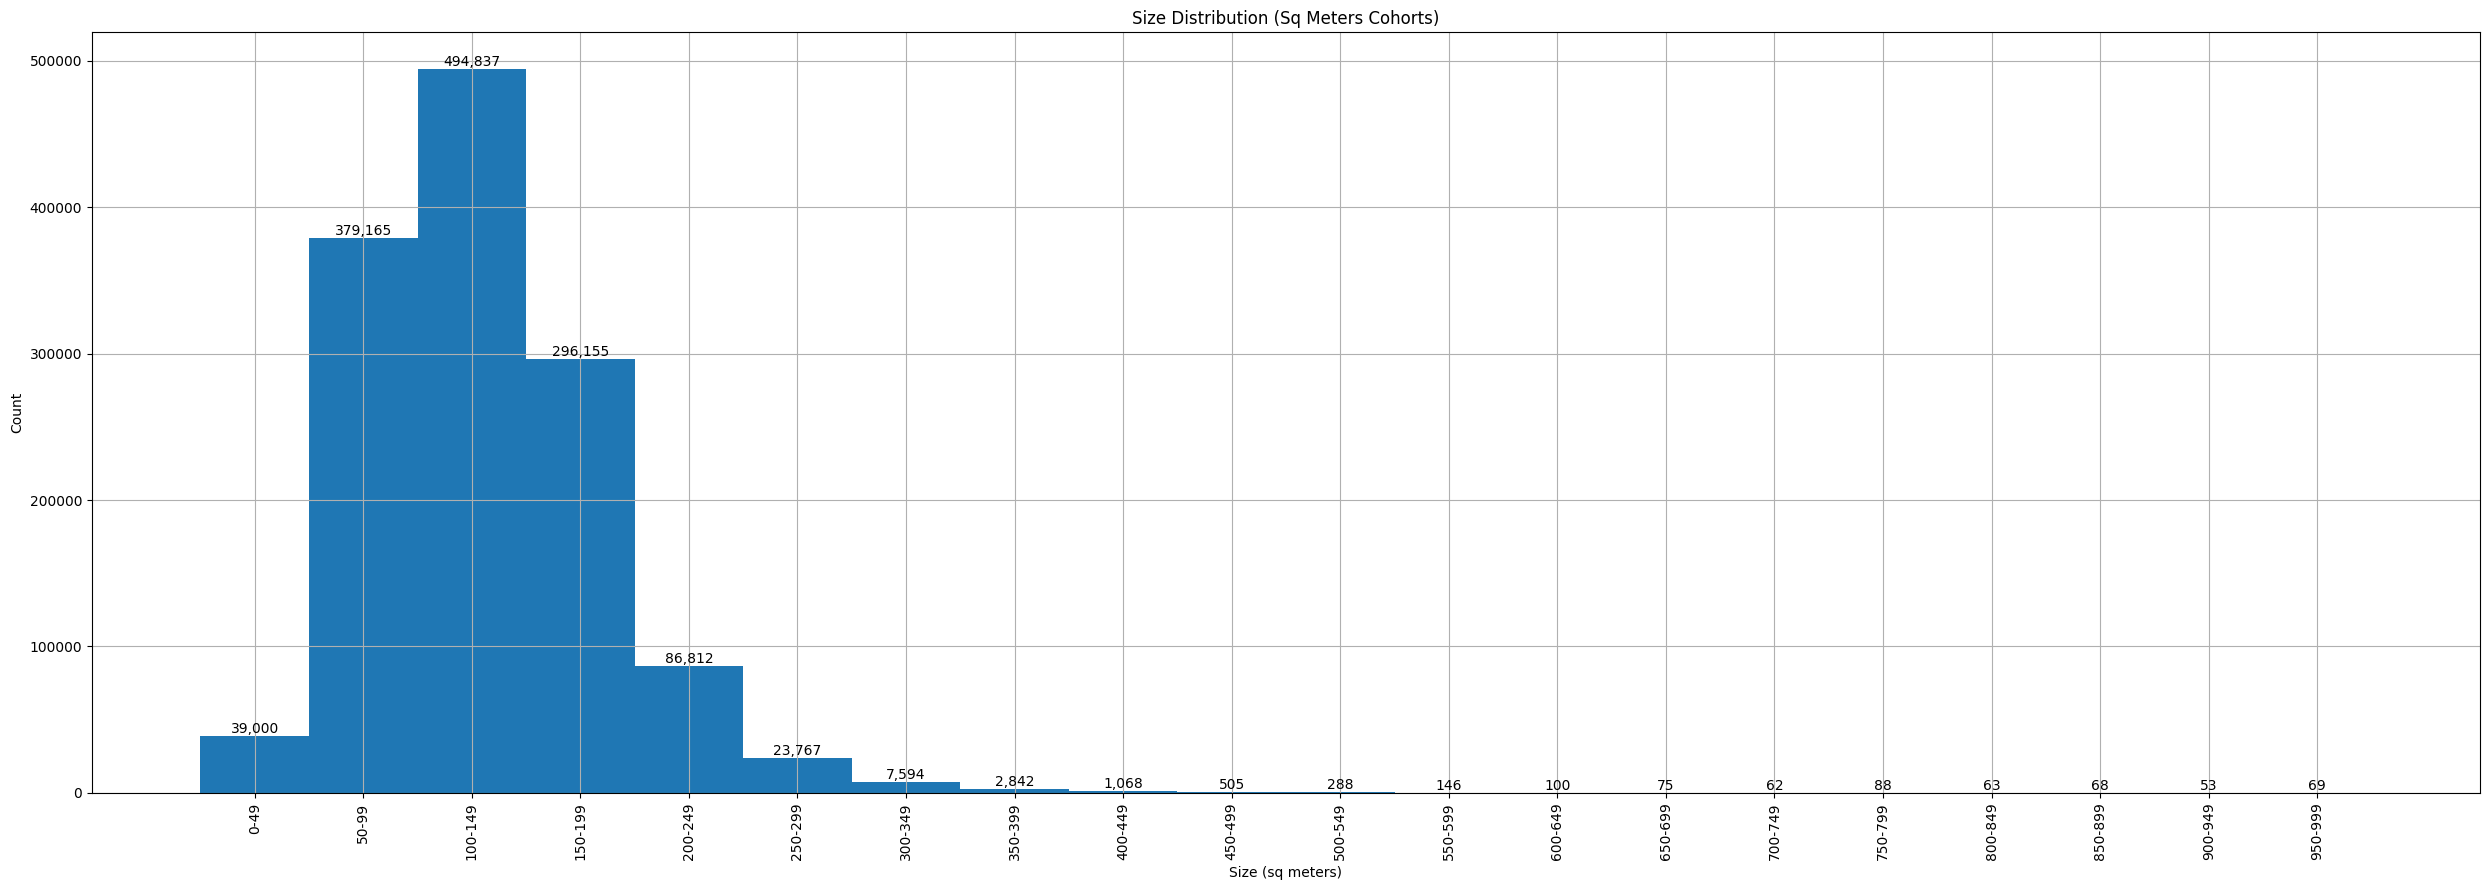

In [75]:
#Find an upward boundary for Size
#Create size cohort bins
numerical_size_data_for_binning = df_train['Size']

#Define bins as: 0-50, 51-100, etc.
max_observed_size = numerical_size_data_for_binning.max()
upper_bound_for_bins = (np.ceil(max_observed_size / 50) + 1) * 50
bins = np.arange(0, upper_bound_for_bins, 50)

#explicitly define bins
binned_size_series = pd.cut(numerical_size_data_for_binning, bins=bins, right=False)
size_counts = binned_size_series.value_counts()
size_counts = size_counts.sort_index()

#Filter out empty bins if any
size_counts = size_counts[size_counts > 0]

#Calculate midpoints and widths for plotting
midpoints = [interval.mid for interval in size_counts.index]
widths = [interval.length for interval in size_counts.index]

plt.figure(figsize=(25, 9))
bars = plt.bar(midpoints, size_counts.values, width=widths)
plt.title('Size Distribution (Sq Meters Cohorts)')
plt.xlabel('Size (sq meters)')
plt.ylabel('Count')

tick_labels = []
for interval in size_counts.index:
    if interval.right == upper_bound_for_bins:
        tick_labels.append(f"{int(interval.left)}+")
    else:
        tick_labels.append(f"{int(interval.left)}-{int(interval.right - 1)}")

plt.xticks(midpoints, tick_labels, rotation=90)
plt.grid(True)

for bar, count in zip(bars, size_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{count:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [77]:
#Establish size cutoff
MAX_SIZE = 350

df_train_filtered = df_train[df_train["Size"] <= MAX_SIZE].copy()

print(df_train.shape)
print(df_train_filtered.shape)

(1332759, 20)
(1327495, 20)


In [78]:
train_df_all_sales = df_train_filtered[df_train_filtered["Date"].dt.year < 2024].copy()
test_df_all_sales  = df_train_filtered[df_train_filtered["Date"].dt.year == 2024].copy()

target = "Purchase Price"

X_train = train_df_all_sales.drop(columns=[target])
y_train = train_df_all_sales[target]

X_test = test_df_all_sales.drop(columns=[target])
y_test = test_df_all_sales[target]

print(X_train.shape)
print(X_test.shape)

(1270054, 19)
(57441, 19)


In [79]:
cat_cols = [
    "House Type",
    "Zip Code",
    "Area",
    "City",
    "Region"
]

num_cols = [
    "Year Built",
    "# of Rooms",
    "Size",
    "Nominal Interest Rate",
    "Annual Danish Inflation Rate",
    "30 year rate",
    "sales_year",
    "% Change Between Offer and Purchase"
]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ]
)


In [80]:
model = Pipeline([
    ("prep", preprocess),
    ("reg", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1500,
        max_depth=12,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  619,931.56
RMSE: 1,060,385.13
R²:   0.7112


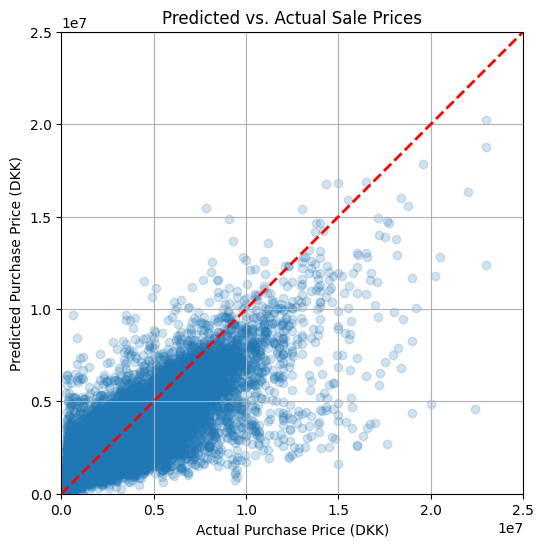

In [100]:
#Compare prediction prices vs actuals
plt.figure(figsize=(14, 6))

plt.scatter(y_test, preds, alpha=0.2)

plt.plot(
    [0, price_max],
    [0, price_max],
    "r--",
    linewidth=2
)


plt.xlim(0, 25000000)
plt.ylim(0, 25000000)

plt.xlabel("Actual Purchase Price (DKK)")
plt.ylabel("Predicted Purchase Price (DKK)")
plt.title("Predicted vs. Actual Sale Prices")
plt.grid(True)

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

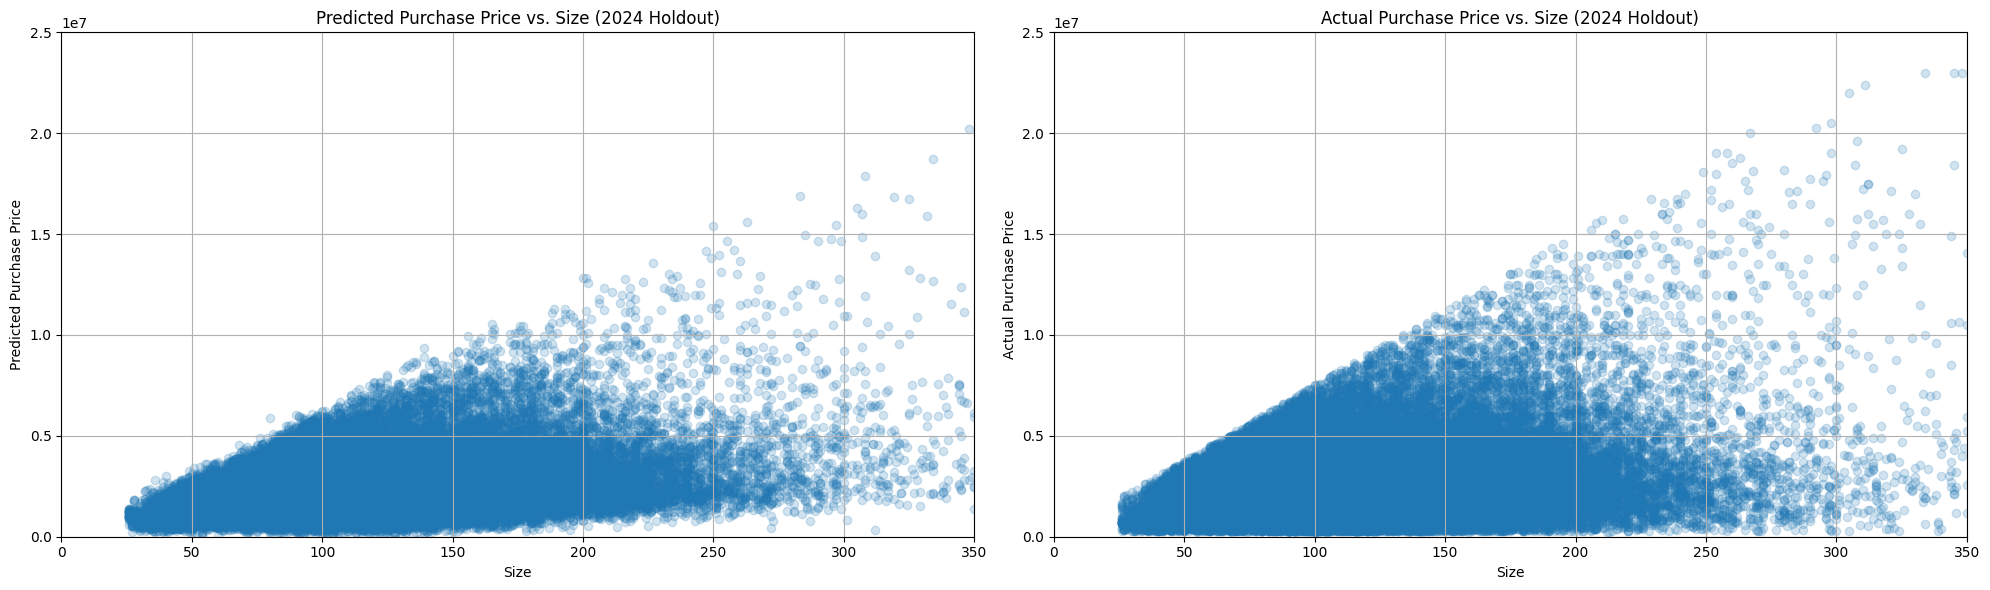

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Predicted Purchase Price vs. Size
axes[0].scatter(X_test['Size'], preds, alpha=0.2)
axes[0].set_xlim(0, 350)
axes[0].set_ylim(0, 25000000)
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Predicted Purchase Price")
axes[0].set_title("Predicted Purchase Price vs. Size (2024 Holdout)")
axes[0].grid(True)


# Plot 2: Actual Purchase Price vs. Size (2024 Holdout)
axes[1].scatter(X_test['Size'], y_test, alpha=0.2)
axes[1].set_xlim(0, 350)
axes[1].set_ylim(0, 25000000)
axes[1].set_xlabel("Size")
axes[1].set_ylabel("Actual Purchase Price")
axes[1].set_title("Actual Purchase Price vs. Size (2024 Holdout)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [54]:
errors = y_test - preds

print(errors.mean())
print(errors.median())

206285.7474399513
76835.0


In [55]:
results = X_test.copy()

results["Actual Price"] = y_test.values
results["Predicted Price"] = preds.astype(int)
results["Residual"] = results["Actual Price"] - results["Predicted Price"]

In [56]:
results["Price Band"] = pd.cut(
    results["Actual Price"],
    bins=[0, 2_000_000, 4_000_000, 6_000_000, 8_000_000, 10_000_000, 12_000_000, 14_000_000, 16_000_000, 18_000_000, 20_000_000, np.inf],
    labels=[
        "0–2M",
        "2–4M",
        "4–6M",
        "6–8M",
        "8–10M",
        "10–12M",
        "12–14M",
        "14–16M",
        "16–18M",
        "18–20M",
        "20M+"
    ]
)

In [57]:
summary = results.groupby("Price Band").agg(
    Homes=("Residual", "count"),
    Mean_Residual=("Residual", "mean"),
    Median_Residual=("Residual", "median"),
    Mean_Actual=("Actual Price", "mean"),
    Mean_Predicted=("Predicted Price", "mean")
)

print(summary)

            Homes  Mean_Residual  Median_Residual   Mean_Actual  \
Price Band                                                        
0–2M        28156  -2.202372e+05        -135106.0  1.202947e+06   
2–4M        19477   2.537908e+05         261060.0  2.870231e+06   
4–6M         6499   8.610097e+05         772105.0  4.848853e+06   
6–8M         2092   1.612607e+06        1482249.5  6.873509e+06   
8–10M         730   2.560015e+06        2340161.5  8.916565e+06   
10–12M        270   3.658093e+06        3316161.5  1.094326e+07   
12–14M        114   4.675013e+06        3856423.0  1.302315e+07   
14–16M         57   6.966837e+06        7375849.0  1.501654e+07   
16–18M         26   7.274600e+06        6242860.0  1.702616e+07   
18–20M         13   8.062791e+06        9068056.0  1.879231e+07   
20M+            7   8.201251e+06        7715606.0  2.202143e+07   

            Mean_Predicted  
Price Band                  
0–2M          1.423185e+06  
2–4M          2.616441e+06  
4–6M        

/tmp/ipykernel_8413/3395706470.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = results.groupby("Price Band").agg(


In [58]:
#Turn summary results into a table
summary_table = summary.style.format({
    'Mean_Residual': int,
    'Median_Residual': int,
    'Mean_Actual': int,
    'Mean_Predicted': int
})

display(summary_table)

,Homes,Mean_Residual,Median_Residual,Mean_Actual,Mean_Predicted
Price Band,,,,,
0–2M,28156,-220237,-135106,1202947,1423184
2–4M,19477,253790,261060,2870231,2616440
4–6M,6499,861009,772105,4848853,3987843
6–8M,2092,1612607,1482249,6873508,5260901
8–10M,730,2560014,2340161,8916565,6356550
10–12M,270,3658092,3316161,10943255,7285162
12–14M,114,4675013,3856423,13023145,8348132
14–16M,57,6966837,7375849,15016538,8049701
16–18M,26,7274599,6242860,17026162,9751562


In [62]:
#adjust predicted prices with mean_residual values to create an adjusted_prediction variable
#For later export to .CSV and Tableau

adjustment_values = {
    "0–2M": -135106,
    "2–4M": 261060,
    "4–6M": 772105,
    "6–8M": 1482249.5,
    "8–10M": 2340161.5,
    "10–12M": 3316161.5,
    "12–14M": 3856423,
    "14–16M": 7375849,
    "16–18M": 6242860,
    "18–20M": 9068056,
    "20M+":  7715606
}

results["Adjusted Predicted Price"] = results["Predicted Price"]

results["Predicted Price Band"] = pd.cut(
    results["Predicted Price"],
    bins=[0, 2_000_000, 4_000_000, 6_000_000, 8_000_000, 10_000_000, 12_000_000, 14_000_000, 16_000_000, 18_000_000, 20_000_000, np.inf],
    labels=[
        "0–2M",
        "2–4M",
        "4–6M",
        "6–8M",
        "8–10M",
        "10–12M",
        "12–14M",
        "14–16M",
        "16–18M",
        "18–20M",
        "20M+"
    ]
)

for band, adjustment in adjustment_values.items():
    results.loc[
        results["Predicted Price Band"] == band,
        "Adjusted Predicted Price"
    ] += adjustment

results.head()

/tmp/ipykernel_8413/3550656886.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7503591.5 7494192.5 9040814.5 ... 8951688.5 8942798.5 8948626.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[


,Date,Quarter,House ID,House Type,Sales Type,Year Built,% Change Between Offer and Purchase,# of Rooms,Size,Price/sq meter,...,Nominal Interest Rate,Annual Danish Inflation Rate,30 year rate,sales_year,Actual Price,Predicted Price,Residual,Price Band,Adjusted Predicted Price,Predicted Price Band
0,2024-10-26,2024Q4,0,Villa,regular_sale,1974,0.0,5,215.0,20232.558594,...,3.1,NaN,NaN,2024,4350000,3910475,439525,4–6M,4171535.0,2–4M
1,2024-10-26,2024Q4,2,Summerhouse,regular_sale,1956,0.0,3,36.0,12500.000000,...,3.1,NaN,NaN,2024,450000,993270,-543270,0–2M,858164.0,0–2M
2,2024-10-26,2024Q4,1,Farm,regular_sale,1955,0.0,3,180.0,36666.667969,...,3.1,NaN,NaN,2024,6600000,3243366,3356634,6–8M,3504426.0,2–4M
4,2024-10-25,2024Q4,4,Villa,regular_sale,1967,0.0,5,176.0,19176.136719,...,3.1,NaN,NaN,2024,3375000,3124638,250362,2–4M,3385698.0,2–4M
5,2024-10-24,2024Q4,14,Villa,regular_sale,1979,0.0,6,208.0,14423.077148,...,3.1,NaN,NaN,2024,3000000,3091919,-91919,2–4M,3352979.0,2–4M
